In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.layers import Conv1D, MaxPooling1D, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import warnings
warnings.filterwarnings("ignore")

In [2]:
MAX_LEN = 500
EPOCHS = 20
BATCH_SIZE = 16

In [4]:
# Load the dataset
rep_df = pd.read_csv('rep_features/repetition_labels.csv')
rep_df.head()

,filepath,label
0,rep_features\REPETITIVE\mfcc_scam1_orig.npy,1
1,rep_features\REPETITIVE\mfcc_scam1_slow.npy,1
2,rep_features\REPETITIVE\mfcc_scam1_fast.npy,1
3,rep_features\REPETITIVE\mfcc_scam1_pitch.npy,1
4,rep_features\REPETITIVE\mfcc_scam1_vol.npy,1


In [5]:
rep_df.label.value_counts(normalize=True)

label
1    0.5
0    0.5
Name: proportion, dtype: float64

In [3]:
def pad_features(features, max_len=MAX_LEN):
    if features.shape[0] < max_len:
        padding = np.zeros((max_len - features.shape[0], features.shape[1]))
        features = np.vstack((features, padding))
    else:
        features = features[:max_len, :]
    return features

In [7]:
X = []
y = []
for _, row in rep_df.iterrows():
    feature = np.load(row["filepath"])
    feature = pad_features(feature)
    X.append(feature)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

In [8]:
X.shape, y.shape

((160, 500, 40), (160,))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((128, 500, 40), (32, 500, 40), (128,), (32,))

In [17]:
model = Sequential()

model.add(Conv1D(32, kernel_size=5, activation='relu',
                 input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(Conv1D(64, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(GlobalAveragePooling1D())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 496, 32)        │         6,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 496, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 248, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 248, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 246, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 246, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 123, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 123, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,249 (67.38 KB)

 Trainable params: 17,057 (66.63 KB)

 Non-trainable params: 192 (768.00 B)

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.5,          # reduce LR by half
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath='models/best_repetition_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_reduction, model_checkpoint]
)

Epoch 1/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6151 - loss: 0.6672
Epoch 1: val_accuracy improved from None to 0.50000, saving model to models/best_repetition_model.keras

Epoch 1: finished saving model to models/best_repetition_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.6328 - loss: 0.6439 - val_accuracy: 0.5000 - val_loss: 2.1172 - learning_rate: 0.0010
Epoch 2/20
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6666 - loss: 0.5792
Epoch 2: val_accuracy did not improve from 0.50000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6562 - loss: 0.5903 - val_accuracy: 0.5000 - val_loss: 1.7534 - learning_rate: 0.0010
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8086 - loss: 0.4993
Epoch 3: val_accuracy did not improve from 0.50000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8047 - loss: 0.4881 - val_accuracy: 0.5000 - val_loss: 1.0086 - learning_rate: 0.0010
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.9375 - loss: 0.0957
Accuracy of our model on test data :  93.75 %


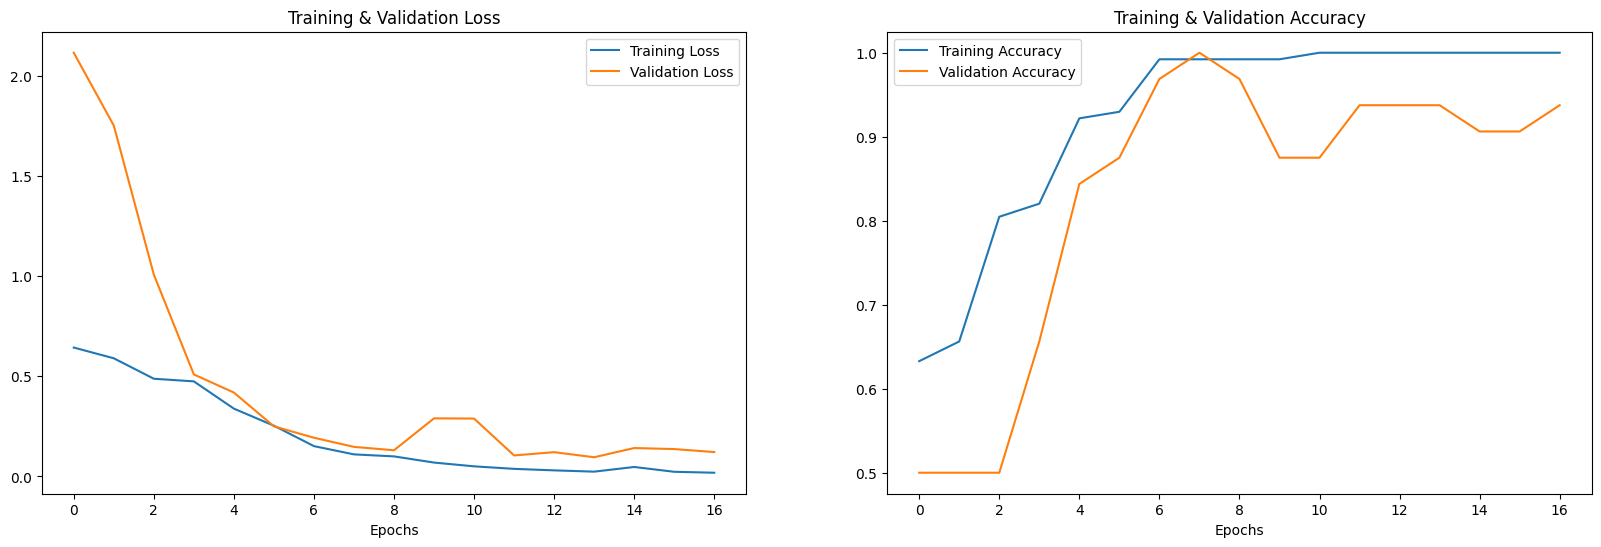

In [20]:
print("Accuracy of our model on test data : " , model.evaluate(X_test, y_test)[1]*100 , "%")

epochs = range(len(history.history['loss']))
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

fig.set_size_inches(20,6)
ax[0].plot(epochs , train_loss , label = 'Training Loss')
ax[0].plot(epochs , test_loss , label = 'Validation Loss')
ax[0].set_title('Training & Validation Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
ax[1].plot(epochs , test_acc , label = 'Validation Accuracy')
ax[1].set_title('Training & Validation Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
plt.show()

In [31]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


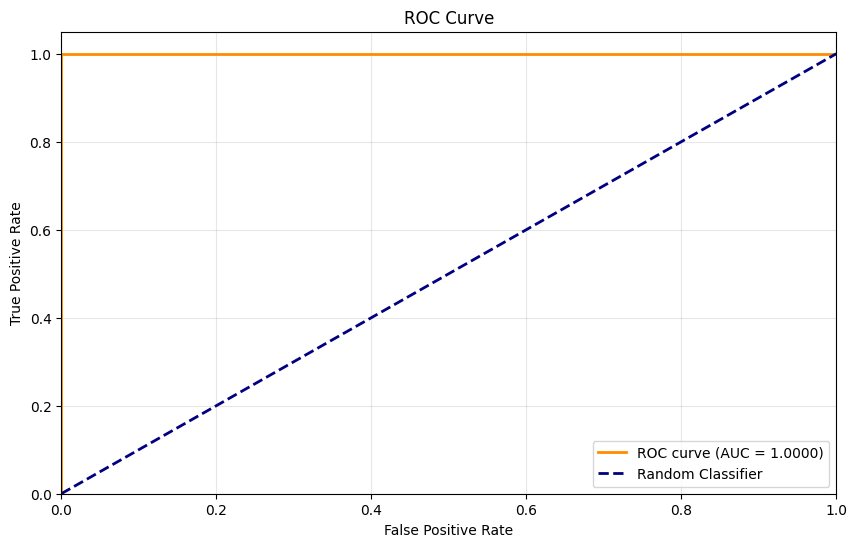

AUC Score: 1.0000


In [37]:
# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [39]:
# Method 1: Youden's J statistic (maximize TPR - FPR)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = _[optimal_idx]

print(f"Threshold = {optimal_threshold:.4f} (optimal)")
y_pred_optimal = np.where(y_pred >= optimal_threshold, 1,0).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimal) * 100:.2f}%")

Threshold = 0.4309 (optimal)
Accuracy: 100.00%


In [40]:
print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



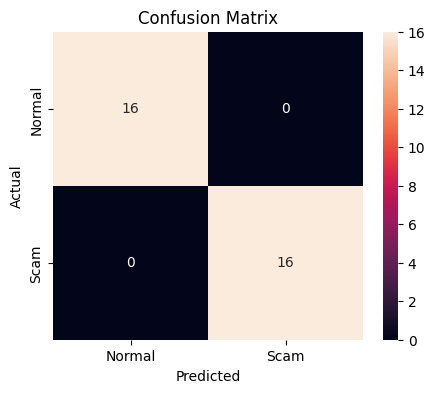

In [41]:
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Normal","Scam"],
            yticklabels=["Normal","Scam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [5]:
from tensorflow.keras.models import load_model
model = load_model(r"models\best_repetition_model.keras")

path = r"rep_features\REPETITIVE\mfcc_scam1_orig.npy"

feature = np.load(path)

In [6]:
feature.shape

(268, 40)

In [8]:
model.predict(np.expand_dims(pad_features(feature), axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


array([[0.9483139]], dtype=float32)